In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import os
import glob

In [86]:
DATA_ROOT_PATH = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_v2"
POWER_MODES = ["HPM", "RPM", "LPM"]
FS_STR_LIST = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]

REF_HI = 2.8
REF_LO = 0.8

FS_LIST = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]                                  # Fs
FI_LIST = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]     # Fi
J_LIST = [1637, 819, 409, 273, 205, 163, 135]                                    # J
BUFFER_SIZE = 8192                                                          # M

hann_window = np.hanning(BUFFER_SIZE)

# SHUNT_VOLTAGE = {
#     "HPM": {"500k": 4.73e-3, "1M": 5.07e-3, "2M": 5.70e-3, "3M": 6.27e-3, "4M": 0.0, "5M": 7.54e-3},
#     "RPM": {"500k": 3.36e-3, "1M": 3.70e-3, "2M": 4.30e-3, "3M": 4.91e-3, "4M": 0.0, "5M": 6.15e-3},
#     "LPM": {"500k": 2.61e-3, "1M": 2.99e-3, "2M": 3.63e-3, "3M": 4.07e-3, "4M": 0.0, "5M": 4.57e-3}, # 5Mhz @ LMP is FAKE!! REMEMBER TO RETEST
# }

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.59e-3, "1M": 4.93e-3, "2M": 5.58e-3, "3M": 6.14e-3, "4M": 6.71e-3, "5M": 7.29e-3, "6M": 7.83e-3},
    "RPM": {"500k": 3.23e-3, "1M": 3.57e-3, "2M": 4.18e-3, "3M": 4.79e-3, "4M": 5.37e-3, "5M": 5.91e-3, "6M": 6.15e-3},
    "LPM": {"500k": 2.49e-3, "1M": 2.87e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 5.83e-3} # 5Mhz @ LMP is FAKE!! REMEMBER TO RETEST
}


SHUNT_RESISTANCE = 1.02 # ohms

#   Fs      |  Fclk_gen |       Fi
# 500kHz    |   8e6     |   99.915 kHz  x
# 1Mhz      |   16e6    |   99.976 kHz  x
# 2Mhz      |   32e6    |   99.854 kHz  x
# 3Mhz      |   48e6    |   99.976 kHz  x
# 4Mhz      |   64e6    |   100.098 kHz
# 5Mhz      |   80e6    |   99.487 kHz  x

In [ ]:
# ── 1. Load raw data ──────────────────────────────────────────────────────────
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    # new format: columns are test_1, test_2, ... test_N
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]

/tmp/ipykernel_931367/2785987698.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


In [98]:
raw_dfs["HPM"].head()

,6M0,6M1,6M2,6M3,6M4,6M5,6M6,6M7,6M8,6M9,...,1M90,1M91,1M92,1M93,1M94,1M95,1M96,1M97,1M98,1M99
0,248,124,154,253,253,116,0,144,0,42,...,152,212,245,233,188,215,169,233,82,245
1,115,127,150,122,124,246,0,128,0,167,...,70,245,245,250,113,249,227,184,158,205
2,113,125,0,252,124,248,0,8,0,158,...,17,245,209,227,39,240,249,105,223,133
3,234,124,8,120,250,250,0,0,0,154,...,8,203,136,170,8,193,235,34,250,53
4,103,124,0,244,249,254,0,0,0,22,...,44,127,59,92,20,115,175,8,235,12


In [88]:

# ── 2. Convert to voltage ─────────────────────────────────────────────────────
waveform_dfs = {pm: raw_dfs[pm] / 255.0 * 2.0 - 1.0 for pm in POWER_MODES}
# waveform_dfs = {pm: (raw_dfs[pm] / 255.0) * (REF_HI - REF_LO) + REF_LO for pm in POWER_MODES}



In [89]:

# ── 3. FFT + average across trials ───────────────────────────────────────────
fft_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for pm in POWER_MODES:
    for fs_str in FS_STR_LIST:
        fs_cols = [col for col in waveform_dfs[pm].columns if col.startswith(fs_str)]
        fft_trials = pd.DataFrame()
        for col in fs_cols:
            # fft_trials[col] = np.abs(np.fft.fft(waveform_dfs[pm][col]))
            # fft_trials[col] = np.abs(np.fft.fft(waveform_dfs[pm][col])) / BUFFER_SIZE

            coherent_gain = np.mean(hann_window)  # ≈ 0.5 for Hann

            fft_trials[col] = np.abs(np.fft.fft(waveform_dfs[pm][col] * hann_window)) / (BUFFER_SIZE * coherent_gain)
        fft_dfs[pm][fs_str] = fft_trials.mean(axis=1)
        # average power, then take sqrt
        # for col in fs_cols:
        #     fft_trials[col] = (np.abs(np.fft.fft(waveform_dfs[pm][col])) / BUFFER_SIZE) ** 2  # power

        # fft_dfs[pm][fs_str] = np.sqrt(fft_trials.mean(axis=1))  # RMS average → back to magnitude




In [90]:

# ── 4. Normalize, convert to dB and dBFS ─────────────────────────────────────
v_dfs    = {pm: pd.DataFrame() for pm in POWER_MODES}
db_dfs   = {pm: pd.DataFrame() for pm in POWER_MODES}
dbfs_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}
f_plots  = {}  # frequency axis per Fs

for pm in POWER_MODES:
    for fs_str, fs, J in zip(FS_STR_LIST, FS_LIST, J_LIST):
        # frequency axis
        fstep = fs / BUFFER_SIZE
        f = np.linspace(0, (BUFFER_SIZE - 1) * fstep, BUFFER_SIZE)
        f_plots[fs_str] = f[0:int(BUFFER_SIZE / 2 + 1)]

        X_mag_plot = 2 * fft_dfs[pm][fs_str][0:int(BUFFER_SIZE / 2 + 1)]
        X_mag_plot.iloc[0] = X_mag_plot.iloc[0] / 2  # DC bin correction

        scale = X_mag_plot.iloc[J]

        v_dfs[pm][fs_str]    = X_mag_plot
        db_dfs[pm][fs_str]   = 20 * np.log10(X_mag_plot.values)
        dbfs_dfs[pm][fs_str] = 20 * np.log10(X_mag_plot.values / scale)

/tmp/ipykernel_931367/1610068362.py:20: RuntimeWarning: divide by zero encountered in log10
  db_dfs[pm][fs_str]   = 20 * np.log10(X_mag_plot.values)
/tmp/ipykernel_931367/1610068362.py:21: RuntimeWarning: divide by zero encountered in log10
  dbfs_dfs[pm][fs_str] = 20 * np.log10(X_mag_plot.values / scale)


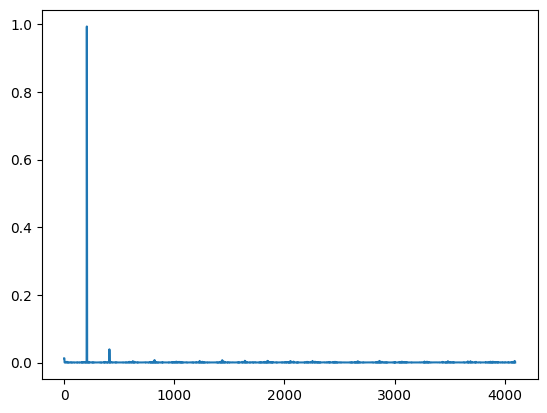

In [91]:
plt.plot(v_dfs["HPM"]["4M"])

In [92]:


POWER_MW = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE)
         for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}


# ── 5. Dynamic Characteristics ────────────────────────────────────────────────
REF_RANGE = (REF_HI - REF_LO) / 2  # full-scale amplitude = 1.0V (2.8-0.8)/2

results = []

for pm in POWER_MODES:
    for fs_str, fs, J in zip(FS_STR_LIST, FS_LIST, J_LIST):

        X_mag_plot = v_dfs[pm][fs_str].values       # already normalized (V)
        X_dbfs     = dbfs_dfs[pm][fs_str]           # already in dBFS
        Fi         = (J / BUFFER_SIZE) * fs

        # ── Harmonic indices (with aliasing, IEEE 1241) ───────────────────
        # NOTE: for low Fs (e.g. 500kHz), J is large so high harmonics fold
        # back. alias() handles this. we skip k=0 (DC) and k=1 (fundamental).
        def alias(harmonic_freq, fs, N):
            a = harmonic_freq % fs
            if a > fs / 2:
                a = fs - a
            return int(round(a / fs * N))

        harmonic_indices = []
        for k in range(2, 11):  # 2nd through 10th harmonic
            idx = alias(k * Fi, fs, BUFFER_SIZE)
            if 0 <= idx < len(X_mag_plot):
                harmonic_indices.append(idx)

        dc_idx   = 0
        fund_idx = J

        # ── SNR ───────────────────────────────────────────────────────────
        # remove DC, fundamental, and all harmonics from noise
        exclude = list(set([dc_idx, fund_idx] + harmonic_indices))
        noise = np.delete(X_mag_plot, exclude)
        # plt.plot(noise)
        noise_rms  = np.sqrt(np.mean(noise**2))
        signal_rms = (X_mag_plot[fund_idx]) / 3 # HMMMM... what should i do about spectral leakage????
        snr = 20 * np.log10(signal_rms / noise_rms)

        # ── SINAD ─────────────────────────────────────────────────────────
        # remove only DC and fundamental; harmonics stay in noise+distortion
        nad = np.delete(X_mag_plot, [dc_idx, fund_idx])
        nad_rms = np.sqrt(np.mean(nad**2))
        sinad = 20 * np.log10(signal_rms / nad_rms)

        # ── ENOB ──────────────────────────────────────────────────────────
        actual_scale = X_mag_plot[fund_idx]
        # enob = (sinad - 1.76 + 20 * np.log10(REF_RANGE / actual_scale)) / 6.02
        enob = (sinad - 1.76) / 6.02

        # ── THD ───────────────────────────────────────────────────────────
        # RSS of 2nd through 10th harmonics in dBFS
        thd_dbfs_vals = np.array([X_dbfs[i] for i in harmonic_indices])
        THD = 20 * np.log10(np.sqrt(np.sum((10 ** (thd_dbfs_vals / 20)) ** 2)))

        # ── SFDR ──────────────────────────────────────────────────────────
        # strongest spur anywhere in spectrum excluding DC and fundamental
        exclude_sfdr = list(set([dc_idx, fund_idx]))
        sfdr_spectrum = X_dbfs.copy()
        sfdr_spectrum[exclude_sfdr] = -np.inf
        SFDR = -np.max(sfdr_spectrum)   # dBFS is negative, so SFDR = |max spur|

        # ── DR ────────────────────────────────────────────────────────────
        # noise floor = RMS of noise bins (already computed), expressed in dBFS
        noise_floor_dbfs = 20 * np.log10(noise_rms / actual_scale)
        DR = -noise_floor_dbfs   # dBFS is negative

        results.append({
            "Power Mode": pm,
            "Fs":         fs_str,
            "ENOB (bits)":       round(enob, 2),
            "SNR (dB)":        round(snr, 2),
            "SINAD (dB)":      round(sinad, 2),
            "THD (dBFS)":        round(THD, 2),
            "SFDR (dBFS)":       round(SFDR, 2),
            "DR (dBFS)":         round(DR, 2),
            "Power (W)": POWER_MW[pm][fs_str],
            "FOMw (J/step)": POWER_MW[pm][fs_str] / (2**enob * fs),
        })

results_df = pd.DataFrame(results, columns=["Power Mode","Fs","ENOB (bits)","SNR (dB)","SINAD (dB)","THD (dBFS)","SFDR (dBFS)","DR (dBFS)", "Power (W)", "FOMw (J/step)"])
results_df.head(50)

,Power Mode,Fs,ENOB (bits),SNR (dB),SINAD (dB),THD (dBFS),SFDR (dBFS),DR (dBFS),Power (W),FOMw (J/step)
0,HPM,500k,4.62,29.55,29.55,-29.80,5.70,39.09,0.000021,1.684112e-12
1,HPM,1M,4.62,29.56,29.56,-30.53,5.86,39.10,0.000024,9.700590e-13
2,HPM,2M,4.62,29.56,29.56,-30.92,5.94,39.10,0.000031,6.212967e-13
3,HPM,3M,4.62,29.56,29.56,-28.40,5.97,39.11,0.000037,5.017280e-13
4,HPM,4M,4.62,29.55,29.55,-27.59,5.98,39.10,0.000044,4.499561e-13
5,HPM,5M,4.25,27.92,27.36,-9.92,6.00,37.46,0.000052,5.464403e-13
6,HPM,6M,3.76,24.88,24.42,-7.68,5.99,34.42,0.000060,7.376085e-13
7,RPM,500k,4.62,29.56,29.56,-30.65,5.70,39.10,0.000010,8.330007e-13
8,RPM,1M,4.62,29.57,29.57,-31.54,5.86,39.11,0.000012,5.081704e-13
9,RPM,2M,4.62,29.56,29.56,-29.09,5.94,39.10,0.000017,3.488614e-13


In [93]:
# pm = "HPM"
# fs_str = "1M"
# fs = 1e6
# J = 819

# # grab just the first trial
# col = [c for c in waveform_dfs[pm].columns if c.startswith(fs_str)][0]
# x = waveform_dfs[pm][col].values

# print(f"N samples: {len(x)}")
# print(f"Min: {x.min():.4f}, Max: {x.max():.4f}, Peak amplitude: {(x.max()-x.min())/2:.4f}")

# # raw FFT of this single trial
# X = np.fft.fft(x)
# X_mag = np.abs(X) / len(x)
# X_mag_plot = 2 * X_mag[:BUFFER_SIZE//2+1]
# X_mag_plot[0] /= 2

# scale = X_mag_plot[J]
# X_dbfs = 20 * np.log10(X_mag_plot / scale)

# nad = np.delete(X_mag_plot, [0, J])
# nad_rms = np.sqrt(np.mean(nad**2))
# sinad = 20 * np.log10(scale / nad_rms)
# enob = (sinad - 1.76) / 6.02

# print(f"Signal peak: {scale:.6f} V")
# print(f"NAD RMS: {nad_rms:.6f} V")
# print(f"SINAD: {sinad:.2f} dB")
# print(f"ENOB: {enob:.2f} bits")

# plt.plot(X_dbfs)
# plt.ylim(-100, 5)
# plt.grid(True)
# plt.title("Single trial dBFS - HPM 1M")
# plt.show()

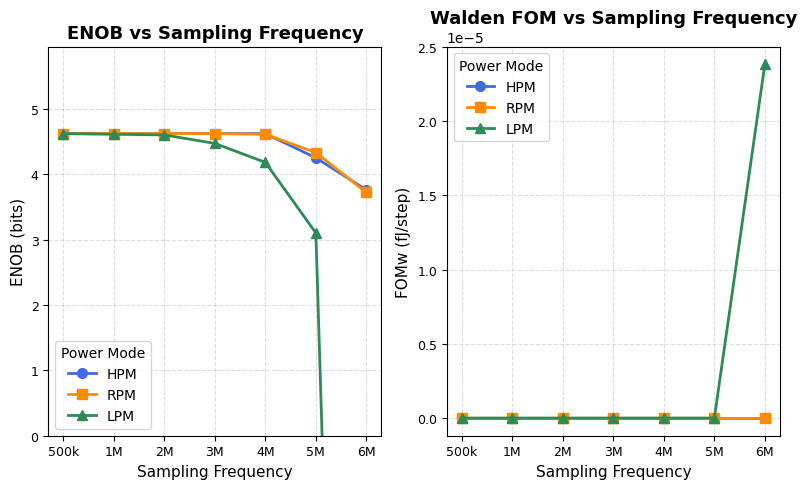

In [94]:
colors  = {"HPM": "royalblue", "RPM": "darkorange", "LPM": "seagreen"}
markers = {"HPM": "o", "RPM": "s", "LPM": "^"}

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))

for pm in POWER_MODES:
    df_pm = results_df[results_df["Power Mode"] == pm]

    ax1.plot(df_pm["Fs"], df_pm["ENOB (bits)"],
             color=colors[pm], marker=markers[pm],
             linewidth=2, markersize=7, label=pm)

    ax2.plot(df_pm["Fs"], df_pm["FOMw (J/step)"],
             color=colors[pm], marker=markers[pm],
             linewidth=2, markersize=7, label=pm)

ax1.set_title("ENOB vs Sampling Frequency", fontsize=13, fontweight="bold")
ax1.set_xlabel("Sampling Frequency", fontsize=11)
ax1.set_ylabel("ENOB (bits)", fontsize=11)
ax1.legend(title="Power Mode", fontsize=10)
ax1.grid(True, alpha=0.4, linestyle="--")
ax1.tick_params(labelsize=9)
ax1.set_ylim(0)

ax2.set_title("Walden FOM vs Sampling Frequency", fontsize=13, fontweight="bold")
ax2.set_xlabel("Sampling Frequency", fontsize=11)
ax2.set_ylabel("FOMw (fJ/step)", fontsize=11)
ax2.legend(title="Power Mode", fontsize=10)
ax2.grid(True, alpha=0.4, linestyle="--")
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

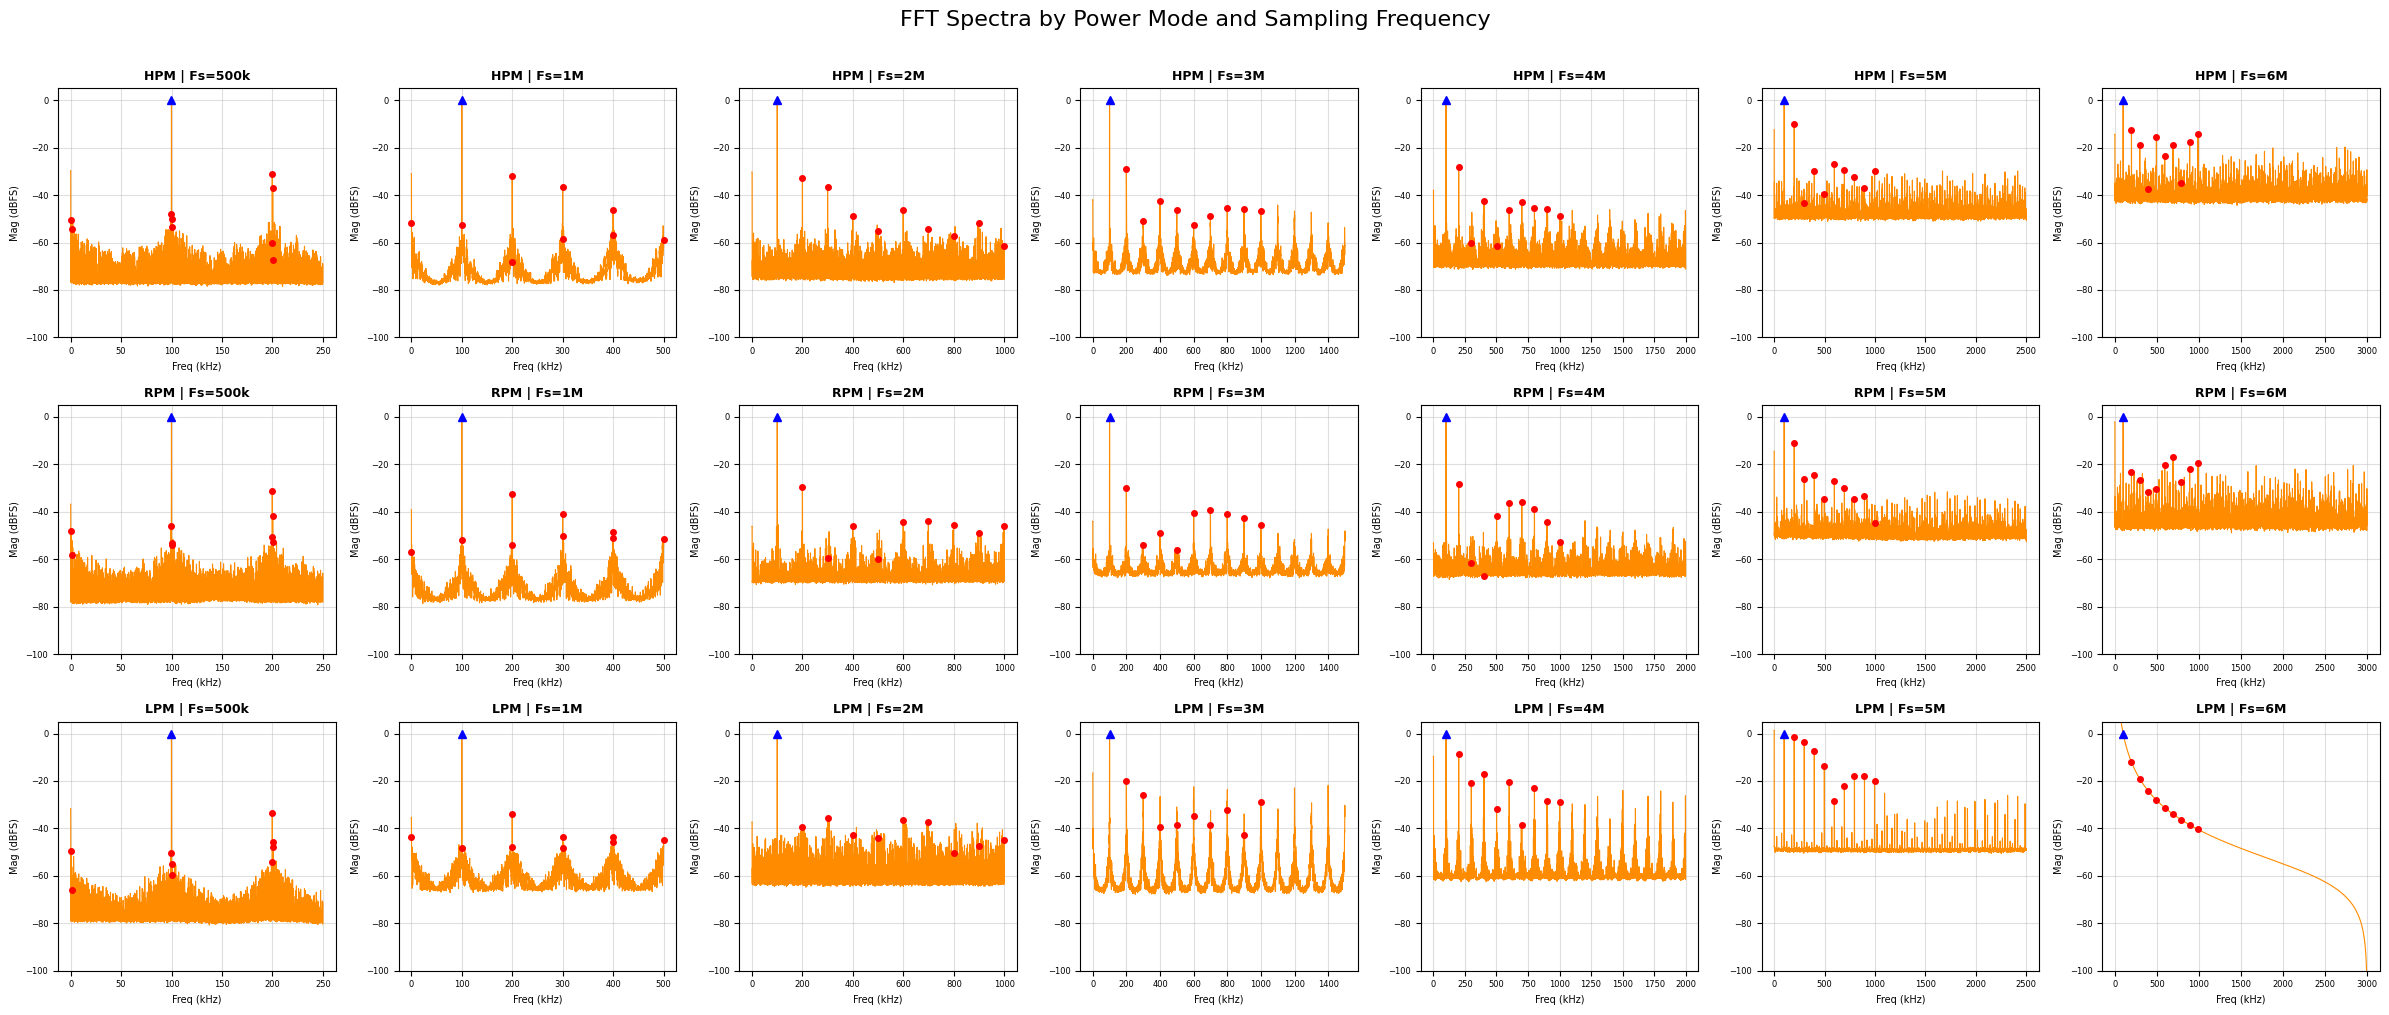

In [95]:
# ── 6. Grid Plot: 3 Power Modes × 5 Fs, dBFS only ───────────────────────────
n_pm = len(POWER_MODES)   # 3
n_fs = len(FS_STR_LIST)   # 5

fig, axes = plt.subplots(
    nrows=n_pm,
    ncols=n_fs,
    figsize=(24, 10)
)
fig.suptitle("FFT Spectra by Power Mode and Sampling Frequency", fontsize=16, y=1.01)

def alias(harmonic_freq, fs, N):
    a = harmonic_freq % fs
    if a > fs / 2:
        a = fs - a
    return int(round(a / fs * N))

for pm_idx, pm in enumerate(POWER_MODES):
    for fs_idx, (fs_str, fs, J) in enumerate(zip(FS_STR_LIST, FS_LIST, J_LIST)):

        ax = axes[pm_idx][fs_idx]

        f_axis = f_plots[fs_str] / 1e3          # Hz → kHz
        X_dbfs = dbfs_dfs[pm][fs_str]
        Fi     = (J / BUFFER_SIZE) * fs

        # ── harmonic indices ──────────────────────────────────────────────
        harmonic_indices = []
        for k in range(2, 11):
            idx = alias(k * Fi, fs, BUFFER_SIZE)
            if 0 <= idx < len(X_dbfs):
                harmonic_indices.append(idx)

        # ── plot ──────────────────────────────────────────────────────────
        ax.plot(f_axis, X_dbfs, linewidth=0.8, color='darkorange')
        ax.plot(f_axis[J], X_dbfs[J], 'b^', markersize=6, label='Fundamental')
        for idx in harmonic_indices:
            ax.plot(f_axis[idx], X_dbfs[idx], 'ro', markersize=4)

        ax.set_title(f"{pm} | Fs={fs_str}", fontsize=9, fontweight='bold')
        ax.set_ylabel("Mag (dBFS)", fontsize=7)
        ax.set_xlabel("Freq (kHz)", fontsize=7)
        ax.set_ylim(-100, 5)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fft_grid.png", dpi=150, bbox_inches='tight')
plt.show()

In [96]:
#      Power Mode     |     Fs     |     ENOB     |     SNR     |     SINAD     |     THD     |     SFDR     |     DR     |   

In [97]:
# we have a lot of different filepaths organized as the following
    # high_power_mode
        # 1.01MSps
        # 3.03MSps
        # 9.1MSps
        # 337.12kSps
    # low_power_mode
        # 1.01MSps
        # 3.03MSps
        # 9.1MSps
        # 337.12kSps
    #regular_power_mode
        # 1.01MSps
        # 3.03MSps
        # 9.1MSps
        # 337.12kSps

# sub folder named as a sampling rate has 5 csv files in them. each one is a different 8192 samples of a sine 
# wave input collected from our ADC

# we eventually want to get a graph that has the sampling rate on the x-axis and the ENOB on the y-axis
# and then there will be 3 different lines, one for each power mode, on the graph

# in order to get ENOB and FOM

    # define constants
        # csv_filename format => bufXXXX_ceXXXX_hiXXXXV_loXXXXV_XPM_TX.csv
            # BUFFER_SIZE = buf{number of samples in csv file}_
            # CE = ce{divider}_
            # REF_HI = hi{high reference voltage in volts}_
            # REF_HI = lo{low reference voltage in volts}_
            # POWER_MODE = {H, L, R}PM_
            # TEST_NUM = T{test number}
        # BASE_CLK_FREQ = 291.33333e6
        # FI = 90e3

        # FS = 1/(((CE+1)/BASE_CLK_FREQ)*16)
        # J = (FI*BUFFER_SIZE)/FS
        # fstep = FS / BUFFER_SIZE
        # f = np.linspace(0, (BUFFER_SIZE-1)*fstep, BUFFER_SIZE)

    # FOR each_power_mode
        # FOR each_sampling_rate
            # FOR each_csv_file
                # calculate the FFT
            # average the FFT's together to get one FFT plot
            # calculate ENOB (and all other dynamic characteristics while your at it)
            # save in a table as the following
                # Power Mode | Sampling Rate | ENOB | SNR (dB) | SINAD (dB) | THD (dbFS) | SFDR | DR |
    # plot frequency on X-axis and ENOB on y-axis